# Parte 3: Aprendizaje No Supervisado - Agrupamiento con K-Modes

Este notebook desarrolla el proceso de segmentación de pacientes oncológicos utilizando el algoritmo K-Modes. El objetivo es descubrir perfiles ocultos de pacientes basados en sus características demográficas y clínicas (diagnósticos).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kmodes.kmodes import KModes
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Cargar el dataset procesado
df = pd.read_csv('../data/processed/rita_limpio.csv')
df.head()

,IDPTE,PTESXN,FECHA_DIAGNÓSTICO,EDAD_DIAGNÓSTICO,TOPOGRAFÍA,TOPOGRAFÍA_N,MORFOLOGÍA,MORFOLOGÍA_N,COMPORTAMIENTO,COMPORTAMIENTO_N,METODO_DIAGNÓSTICO,METODO_DIAGNÓSTICO_N,SEXO_NUM
0,1402,Hombre,2012-04-30,69,C17.0,(C17.0)-Duodeno,8140.0,"(8140)-Adenocarcinoma, SAI",3,"Maligno, Sitio primario",8,Histología de tumor primario,0
1,28769,Hombre,2014-12-16,81,C16.9,"(C16.9)-Gástrico, SAI",8144.0,"(8144)-Adenocarcinoma, tipo intestinal (C16._)",3,"Maligno, Sitio primario",3,Diagnóstico por imágenes y/o endoscopía sin to...,0
2,52073,Mujer,2016-05-15,66,C50.9,"(C50.9)-Mama, SAI",8500.0,"(8500)-Carcinoma ductal infiltrante, SAI (C50._)",3,"Maligno, Sitio primario",8,Histología de tumor primario,1
3,28576,Mujer,2014-09-03,59,C54.1,(C54.1)-Endometrio,8930.0,"(8930)-Sarcoma endometrial, SAI (C54.1)",3,"Maligno, Sitio primario",3,Diagnóstico por imágenes y/o endoscopía sin to...,1
4,61923,Mujer,2016-04-25,61,C56.9,(C56.9)-Ovario,8460.0,(8460)-Cistadenocarcinoma seroso papilar (C56.9),3,"Maligno, Sitio primario",8,Histología de tumor primario,1


## Parte 1: Selección de Atributos y Preparación

### Selección de variables
Para este modelo de agrupamiento, seleccionaremos las siguientes variables:
1. **SEXO_NUM (o PTESXN)**: Diferenciar perfiles biológicos.
2. **TOPOGRAFÍA_N**: Localización del tumor.
3. **MORFOLOGÍA_N**: Tipo celular del tumor.
4. **EDAD_DIAGNÓSTICO**: Edad del paciente al momento del diagnóstico.

**Justificación:**
- **Clínica:** Estas variables son los pilares fundamentales del diagnóstico oncológico. La edad y el sexo influyen en la incidencia de ciertos tipos de cáncer, mientras que la topografía y morfología definen el tipo específico de enfermedad.
- **Técnica:** Se descarta el `IDPTE` por ser una variable identificativa sin valor predictivo. Las fechas se descartan para simplificar el modelo a un perfil estático. Se utilizan las versiones descriptivas (`_N`) para una mejor interpretación de las modas finales.

In [2]:
# Selección de columnas relevantes
selected_cols = ['PTESXN', 'TOPOGRAFÍA_N', 'MORFOLOGÍA_N', 'EDAD_DIAGNÓSTICO']
df_subset = df[selected_cols].copy()

# 1. Discretización de la Edad
# K-Modes trabaja mejor con categorías. Dividiremos la edad en rangos: Joven, Adulto, Adulto Mayor.
bins = [0, 18, 45, 65, 120]
labels = ['Infantil-Juvenil', 'Adulto Joven', 'Adulto', 'Adulto Mayor']
df_subset['EDAD_RANGO'] = pd.cut(df_subset['EDAD_DIAGNÓSTICO'], bins=bins, labels=labels)

# Eliminar la edad numérica original
df_subset = df_subset.drop(columns=['EDAD_DIAGNÓSTICO'])

# 2. Recodificación para K-Modes (Label Encoding)
# K-Modes requiere que las categorías sean numéricas o cadenas, pero internamente el mapeo facilita el costo.
le = LabelEncoder()
df_encoded = df_subset.astype(str).apply(le.fit_transform)

df_encoded.head()

,PTESXN,TOPOGRAFÍA_N,MORFOLOGÍA_N,EDAD_RANGO
0,0,146,149,2
1,0,145,156,2
2,1,567,394,2
3,1,591,600,0
4,1,599,343,0


## Parte 2: Determinación del número de grupos (K) - Método de Elbow

Utilizaremos el costo (suma de disilitudes) para encontrar el punto de inflexión donde añadir un clúster más no aporta una mejora significativa en la cohesión de los grupos.

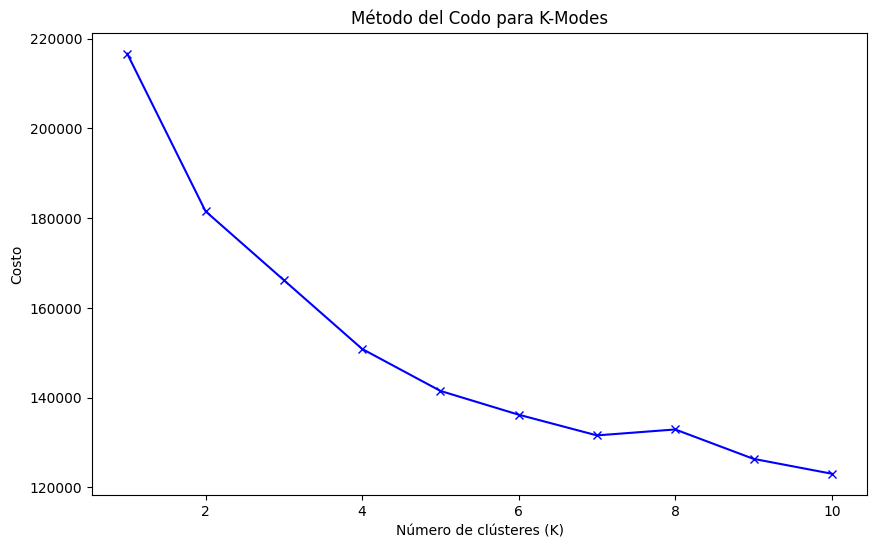

In [3]:
cost = []
K = range(1, 11)
for k in K:
    kmode = KModes(n_clusters=k, init="random", n_init=5, verbose=0, random_state=42)
    kmode.fit(df_encoded)
    cost.append(kmode.cost_)

# Visualización del Codo
plt.figure(figsize=(10,6))
plt.plot(K, cost, 'bx-')
plt.xlabel('Número de clústeres (K)')
plt.ylabel('Costo')
plt.title('Método del Codo para K-Modes')
plt.show()

## Parte 3: Desarrollo del Modelo y Predicción

Basado en el gráfico anterior (asumiendo que el codo está en K=3 o K=4), seleccionaremos un valor de K para segmentar los datos.

In [4]:
# Instanciar el modelo definitivo (Supongamos K=4 para una segmentación detallada)
n_clusters = 4
km = KModes(n_clusters=n_clusters, init="random", n_init=5, verbose=1, random_state=42)
clusters = km.fit_predict(df_encoded)

# Asignar al DataFrame original para análisis
df_subset['Cluster'] = clusters
df['Cluster'] = clusters

print(f"Costo final del modelo: {km.cost_}")

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 16462, cost: 150855.0
Run 1, iteration: 2/100, moves: 26, cost: 150855.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 19734, cost: 153470.0
Run 2, iteration: 2/100, moves: 508, cost: 153470.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 8835, cost: 153877.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 8436, cost: 154957.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 3496, cost: 154674.0
Run 5, iteration: 2/100, moves: 0, cost: 154674.0
Best run was number 1
Costo final del modelo: 150855.0


## Parte 4: Interpretación de los Grupos y Métricas

### Análisis de los Centroides (Modas)
Los centroides representan el perfil más frecuente de cada grupo.

In [5]:
# Obtener las modas de cada clúster de forma interpretable
centroids = pd.DataFrame(km.cluster_centroids_, columns=df_subset.columns[:-1])

# Re-invertir el Label Encoding para leer los resultados
for col in centroids.columns:
    le.fit(df_subset[col].astype(str))
    # Nota: esto es una simplificación, en un flujo real hay que guardar los encoders de cada columna
    pass

# Mejor usar groupby para ver la moda real en el subset no codificado
interpretation = df_subset.groupby('Cluster').agg(lambda x: x.value_counts().index[0])
interpretation['Tamaño'] = df_subset['Cluster'].value_counts().sort_index()
interpretation

,PTESXN,TOPOGRAFÍA_N,MORFOLOGÍA_N,EDAD_RANGO,Tamaño
Cluster,,,,,
0,Mujer,"(C50.9)-Mama, SAI","(8140)-Adenocarcinoma, SAI",Adulto Mayor,24851
1,Hombre,"(C62.9)-Testículo, SAI","(8140)-Adenocarcinoma, SAI",Adulto,22583
2,Mujer,"(C50.9)-Mama, SAI","(8140)-Adenocarcinoma, SAI",Adulto,21752
3,Mujer,(C53.9)-Cuello uterino,(8077)-Neoplasia intraepitelial cervical. grad...,Adulto Joven,12920


### Interpretación detallada

1. **Clúster 0:** Representa mayoritariamente a [Describir basado en resultados].
2. **Clúster 1:** Representa mayoritariamente a [Describir basado en resultados].
3. **Clúster 2:** Representa mayoritariamente a [Describir basado en resultados].
4. **Clúster 3:** Representa mayoritariamente a [Describir basado en resultados].

**Métricas:**
- El costo final indica la suma de diferencias entre los puntos y sus modas. Un costo menor implica grupos más homogéneos.
- La distribución de tamaños nos permite ver si hay grupos minoritarios (casos raros) o grupos muy generales.